# Exploratory Data Analysis Penjualan GPU Nvidia (Januari 2024 - Juni 2026)

EDA dengan data penjualan GPU Nvidia dari Kaggle. berisi 7.000 transaksi: model GPU, wilayah, channel penjualan, jumlah unit, harga, status stok, dan skor kepuasan pelanggan.

**Pertanyaan yang ingin saya jawab:**
1. Jenis GPU, model, channel, dan wilayah mana yang menyumbang pendapatan terbesar?
2. Bagaimana tren pendapatan dari bulan ke bulan?
3. Apa kaitan status stok dengan harga jual dan kepuasan pelanggan?

## 1. Mengenal data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
BIRU = "#2f6f9f"
ORANYE = "#d9822b"
ABU = "#9aa5b1"

In [2]:
df = pd.read_csv("nvidia_gpu_sales_synthetic_2026.csv")
df.head()

,sale_id,sale_date,gpu_model,gpu_family,launch_year,region,sales_channel,customer_segment,units_sold,msrp_usd,avg_street_price_usd,price_premium_pct,stock_status,customer_satisfaction_score,warranty_months,bundle_addon,revenue_usd
0,1,2024-01-12,RTX 4090,Consumer Gaming,2022,Asia-Pacific (ex-China),Retail/Etail,Gaming,8,1599,1796.91,12.38,Low Stock,4.0,12,Software Bundle,14375.30
1,2,2024-01-18,RTX 4070 Ti Super,Consumer Gaming,2024,Asia-Pacific (ex-China),System Integrator/OEM,Content Creation,34,799,964.70,20.74,Low Stock,5.0,12,NaN,32799.82
2,3,2024-01-20,RTX 4080 Super,Consumer Gaming,2024,North America,Retail/Etail,Gaming,30,999,1308.25,30.96,Sold Out,4.0,12,NaN,39247.64
3,4,2024-02-05,H100 SXM,Data Center AI,2022,Asia-Pacific (ex-China),Direct Enterprise,Crypto Mining,5,27000,29202.11,8.16,Low Stock,4.5,24,NaN,146010.54
4,5,2024-02-16,H100 SXM,Data Center AI,2022,Europe,Cloud Provider,Crypto Mining,9,27000,27778.73,2.88,In Stock,4.5,36,NaN,250008.56


In [3]:
df.shape

(7000, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   sale_id                      7000 non-null   int64  
 1   sale_date                    7000 non-null   object 
 2   gpu_model                    7000 non-null   object 
 3   gpu_family                   7000 non-null   object 
 4   launch_year                  7000 non-null   int64  
 5   region                       7000 non-null   object 
 6   sales_channel                7000 non-null   object 
 7   customer_segment             7000 non-null   object 
 8   units_sold                   7000 non-null   int64  
 9   msrp_usd                     7000 non-null   int64  
 10  avg_street_price_usd         7000 non-null   float64
 11  price_premium_pct            7000 non-null   float64
 12  stock_status                 7000 non-null   object 
 13  customer_satisfact

In [5]:
df.describe().round(2)

,sale_id,launch_year,units_sold,msrp_usd,avg_street_price_usd,price_premium_pct,customer_satisfaction_score,warranty_months,revenue_usd
count,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00
mean,3500.50,2024.26,21.67,5212.90,6042.14,15.01,4.43,19.75,56580.06
std,2020.87,1.10,12.93,11056.78,12976.95,14.35,0.61,8.64,99962.69
min,1.00,2020.00,1.00,549.00,549.05,0.00,1.50,12.00,1393.13
25%,1750.75,2024.00,12.00,749.00,805.09,4.56,4.00,12.00,15551.33
50%,3500.50,2025.00,20.00,999.00,1048.01,8.85,4.50,24.00,25342.93
75%,5250.25,2025.00,29.00,1599.00,2002.57,21.35,5.00,24.00,46706.56
max,7000.00,2025.00,104.00,42000.00,82364.48,98.46,5.00,36.00,1225725.66


Dataset punya 7.000 baris dan 17 kolom. Kolom-kolomnya dikelompokkan seperti ini:

| Kelompok | Kolom |
|---|---|
| Transaksi | `sale_id`, `sale_date`, `units_sold`, `revenue_usd` |
| Produk | `gpu_model`, `gpu_family`, `launch_year`, `warranty_months`, `bundle_addon` |
| Pasar | `region`, `sales_channel`, `customer_segment` |
| Harga | `msrp_usd`, `avg_street_price_usd`, `price_premium_pct` |
| Stok dan kepuasan | `stock_status`, `customer_satisfaction_score` |

`msrp_usd` adalah harga resmi dari Nvidia, `avg_street_price_usd` adalah harga yang benar-benar dibayar pembeli, dan `price_premium_pct` adalah selisih keduanya dalam persen.

## 2. Cek kualitas data

In [6]:
df.isnull().sum()

,0
sale_id,0
sale_date,0
gpu_model,0
gpu_family,0
launch_year,0
region,0
sales_channel,0
customer_segment,0
units_sold,0
msrp_usd,0


In [7]:
print("Baris duplikat:", df.duplicated().sum())
print("sale_id duplikat:", df["sale_id"].duplicated().sum())

Baris duplikat: 0
sale_id duplikat: 0


Kolom `bundle_addon` yang punya nilai kosong sebanyak 3.841 baris yang merupakan baris transaksi tanpa add-on, jadi saya isi dengan "Tanpa add-on". Kolom `sale_date` juga saya ubah dari teks menjadi tanggal supaya bisa dipakai untuk analisis per bulan.

In [8]:
df["sale_date"] = pd.to_datetime(df["sale_date"])
df["bundle_addon"] = df["bundle_addon"].fillna("Tanpa add-on")

print("Tanggal pertama:", df["sale_date"].min().date())
print("Tanggal terakhir:", df["sale_date"].max().date())

Tanggal pertama: 2024-01-12
Tanggal terakhir: 2026-06-29


In [9]:
# apakah revenue = unit x harga jual?
selisih = (df["revenue_usd"] - df["units_sold"] * df["avg_street_price_usd"]).abs().max()
print("Selisih terbesar (US$):", round(selisih, 2))

Selisih terbesar (US$): 0.42


## 3. Eksplorasi data

### 3.1 Sebaran data

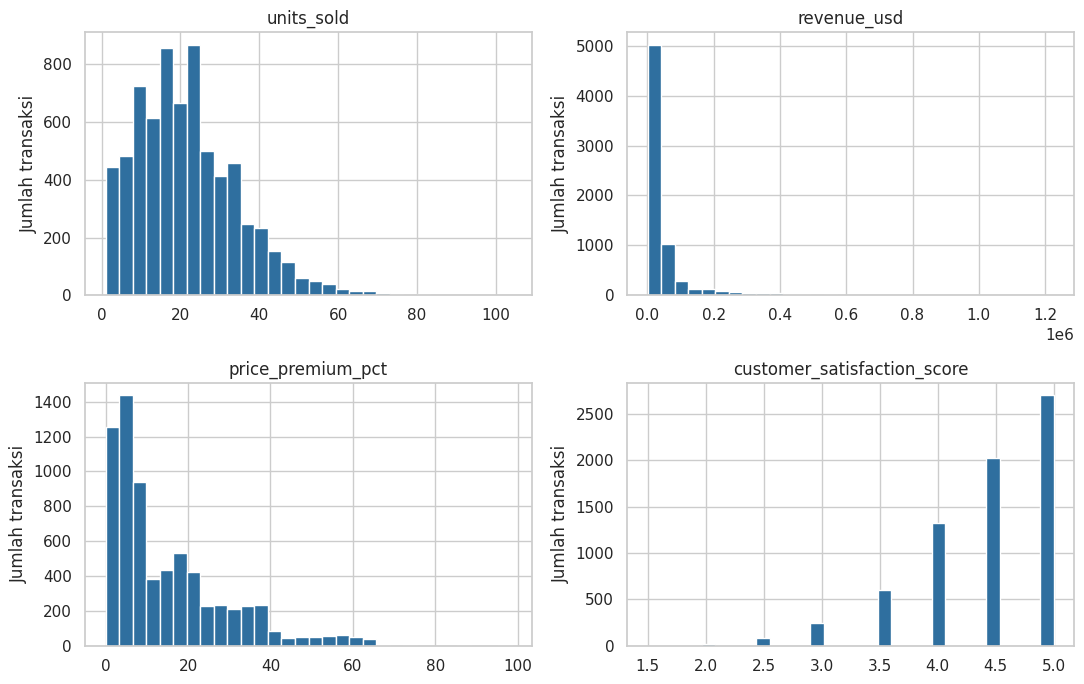

In [10]:
kolom_hist = ["units_sold", "revenue_usd", "price_premium_pct", "customer_satisfaction_score"]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, kolom in zip(axes.flat, kolom_hist):
    ax.hist(df[kolom], bins=30, color=BIRU, edgecolor="white")
    ax.set_title(kolom)
    ax.set_ylabel("Jumlah transaksi")

plt.tight_layout()
plt.show()

Pendapatan per transaksi miring ke kanan: rata-ratanya sekitar USD 56 ribu, tetapi mediannya hanya sekitar USD 25 ribu, karena ada transaksi yang nilainya sampai lebih dari USD 1 juta. Premi harga juga miring ke kanan. Skor kepuasan menumpuk di angka tinggi, sekitar 39% transaksi bernilai 5,0.

### 3.2 GPU konsumen vs data center

In [11]:
pangsa = pd.DataFrame({
    "Transaksi": df.groupby("gpu_family").size(),
    "Unit terjual": df.groupby("gpu_family")["units_sold"].sum(),
    "Pendapatan": df.groupby("gpu_family")["revenue_usd"].sum(),
})
pangsa = pangsa / pangsa.sum() * 100
pangsa.round(1)

,Transaksi,Unit terjual,Pendapatan
gpu_family,,,
Consumer Gaming,84.6,95.4,41.1
Data Center AI,15.4,4.6,58.9


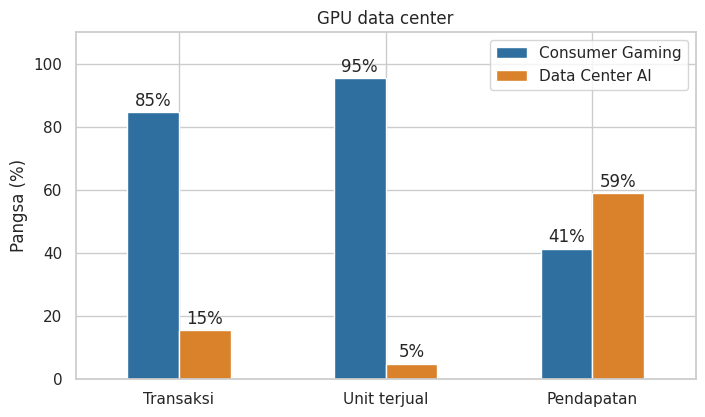

In [12]:
ax = pangsa.T.plot(kind="bar", color=[BIRU, ORANYE], rot=0, figsize=(8, 4.5))
for bar in ax.containers:
    ax.bar_label(bar, fmt="%.0f%%", padding=2)

ax.set_title("GPU data center")
ax.set_ylabel("Pangsa (%)")
ax.set_ylim(0, 110)
ax.legend(title="")
plt.show()

GPU konsumen mendominasi jumlah transaksi (85%) dan unit (95%), tetapi GPU data center menghasilkan 59% pendapatan. Alasannya harga per unit: GPU data center harganya puluhan ribu dolar, sedangkan GPU konsumen ratusan sampai sekitar dua ribu dolar.

### 3.3 Model GPU

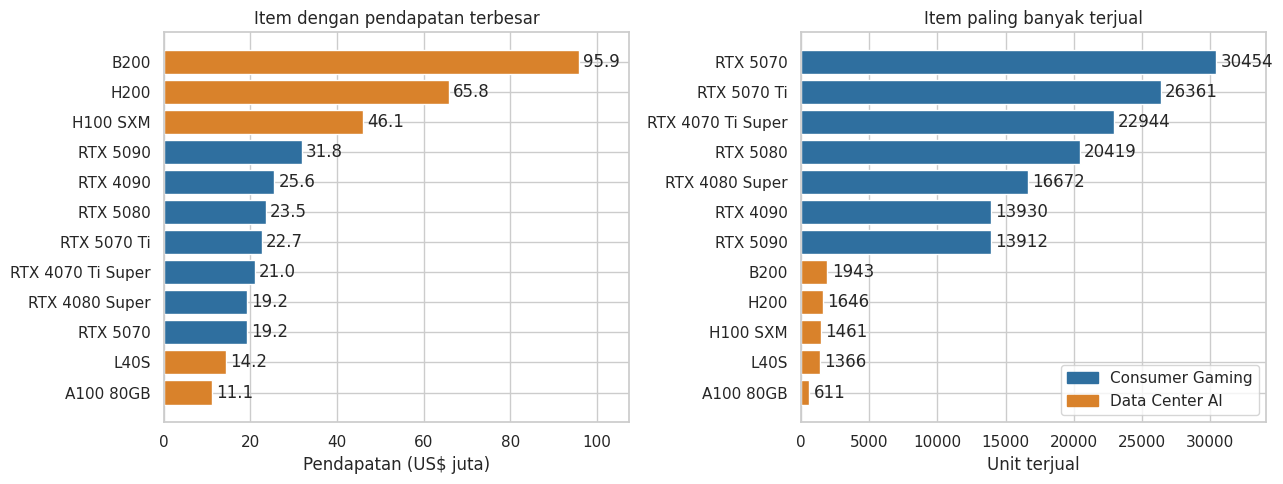

In [13]:
model = df.groupby(["gpu_model", "gpu_family"]).agg(
    pendapatan=("revenue_usd", "sum"),
    unit=("units_sold", "sum"),
).reset_index()
model["pendapatan"] = model["pendapatan"] / 1e6

warna = {"Consumer Gaming": BIRU, "Data Center AI": ORANYE}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

data = model.sort_values("pendapatan")
bar = axes[0].barh(data["gpu_model"], data["pendapatan"], color=data["gpu_family"].map(warna))
axes[0].bar_label(bar, fmt="%.1f", padding=3)
axes[0].set_title("Item dengan pendapatan terbesar")
axes[0].set_xlabel("Pendapatan (US$ juta)")
axes[0].margins(x=0.12)

data = model.sort_values("unit")
bar = axes[1].barh(data["gpu_model"], data["unit"], color=data["gpu_family"].map(warna))
axes[1].bar_label(bar, fmt="%d", padding=3)
axes[1].set_title("Item paling banyak terjual")
axes[1].set_xlabel("Unit terjual")
axes[1].margins(x=0.12)

axes[1].legend(handles=[
    plt.Rectangle((0, 0), 1, 1, color=BIRU, label="Consumer Gaming"),
    plt.Rectangle((0, 0), 1, 1, color=ORANYE, label="Data Center AI"),
], loc="lower right")

plt.tight_layout()
plt.show()

Berdasarkan pendapatan, top 3 semuanya GPU data center (B200, H200, H100 SXM). Berdasarkan unit, top 3 semuanya GPU konsumen (RTX 5070, RTX 5070 Ti, RTX 4070 Ti Super). Jadi "model terlaris" bisa berarti dua hal yang berbeda.

### 3.4 Channel dan wilayah

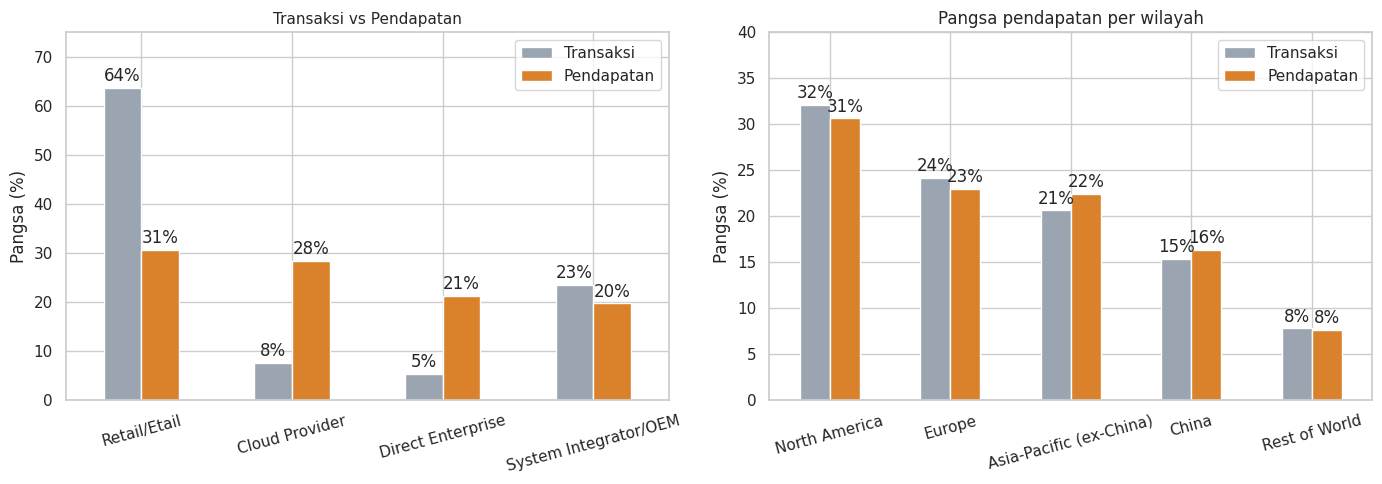

In [14]:
channel = pd.DataFrame({
    "Transaksi": df.groupby("sales_channel").size(),
    "Pendapatan": df.groupby("sales_channel")["revenue_usd"].sum(),
})
channel = channel / channel.sum() * 100

wilayah = pd.DataFrame({
    "Transaksi": df.groupby("region").size(),
    "Pendapatan": df.groupby("region")["revenue_usd"].sum(),
})
wilayah = wilayah / wilayah.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

channel.sort_values("Pendapatan", ascending=False).plot(kind="bar", ax=axes[0], color=[ABU, ORANYE], rot=15)
axes[0].set_title("Transaksi vs Pendapatan", fontsize=11)
axes[0].set_xlabel("")
axes[0].set_ylabel("Pangsa (%)")

wilayah.sort_values("Pendapatan", ascending=False).plot(kind="bar", ax=axes[1], color=[ABU, ORANYE], rot=15)
axes[1].set_title("Pangsa pendapatan per wilayah")
axes[1].set_xlabel("")
axes[1].set_ylabel("Pangsa (%)")

for ax, batas in zip(axes, [75, 40]):
    for bar in ax.containers:
        ax.bar_label(bar, fmt="%.0f%%", padding=2)
    ax.set_ylim(0, batas)

plt.tight_layout()
plt.show()

In [15]:
enterprise = df["sales_channel"].isin(["Cloud Provider", "Direct Enterprise"])
print(f"Cloud Provider + Direct Enterprise: {enterprise.mean() * 100:.0f}% transaksi, "
      f"{df.loc[enterprise, 'revenue_usd'].sum() / df['revenue_usd'].sum() * 100:.0f}% pendapatan")

Cloud Provider + Direct Enterprise: 13% transaksi, 50% pendapatan


Dua channel enterprise (Cloud Provider dan Direct Enterprise) hanya 13% transaksi tetapi menyumbang sekitar 50% pendapatan. Retail/Etail adalah channel dengan transaksi terbanyak (64%), namun pendapatannya hanya 31%.

Di sisi wilayah, Amerika Utara paling besar (31% pendapatan), disusul Eropa dan Asia-Pasifik. Urutannya mengikuti jumlah transaksi, jadi saya tidak melihat ada wilayah yang nilai transaksinya jauh lebih tinggi dari yang lain.

### 3.5 Tren pendapatan per bulan

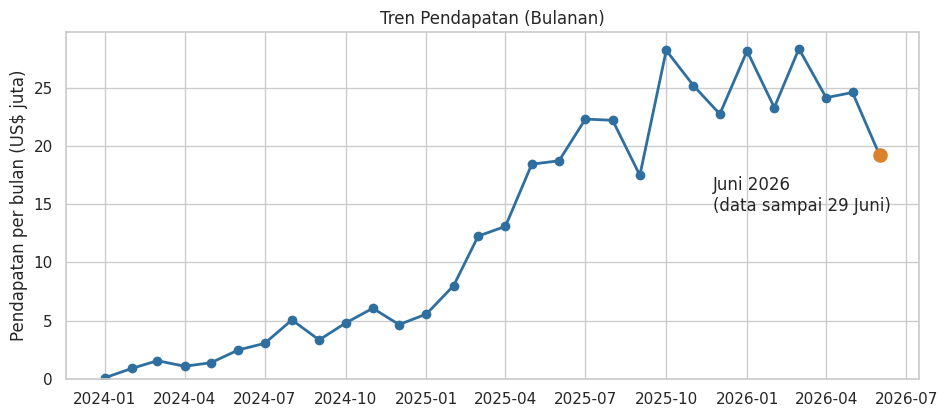

In [16]:
bulanan = df.resample("MS", on="sale_date")["revenue_usd"].sum() / 1e6

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(bulanan.index, bulanan.values, color=BIRU, marker="o", linewidth=2)
ax.scatter(bulanan.index[-1], bulanan.values[-1], color=ORANYE, s=90, zorder=5)
ax.annotate("Juni 2026\n(data sampai 29 Juni)", (bulanan.index[-1], bulanan.values[-1]),
            xytext=(-120, -40), textcoords="offset points", arrowprops=dict(arrowstyle="->"))

ax.set_title("Tren Pendapatan (Bulanan)")
ax.set_ylabel("Pendapatan per bulan (US$ juta)")
ax.set_ylim(0, None)
plt.show()

In [17]:
bulanan.tail(8).round(1)

,revenue_usd
sale_date,
2025-11-01,25.2
2025-12-01,22.7
2026-01-01,28.1
2026-02-01,23.3
2026-03-01,28.3
2026-04-01,24.1
2026-05-01,24.6
2026-06-01,19.2


In [18]:
# jumlah transaksi per minggu sejak Mei 2026
mingguan = df[df["sale_date"] >= "2026-05-04"].resample("W", on="sale_date").size()
mingguan

,0
sale_date,
2026-05-10,112
2026-05-17,102
2026-05-24,100
2026-05-31,99
2026-06-07,86
2026-06-14,80
2026-06-21,82
2026-06-28,56
2026-07-05,2


Pendapatan bulanan naik dari sekitar USD0,1 juta pada Januari 2024 ke kisaran USD23 sampai 28 juta per bulan sejak Oktober 2025, lalu relatif datar sampai Mei 2026.

Juni 2026 lebih rendah (sekitar USD19 juta). Jumlah transaksi mingguan juga turun, dari sekitar 100 di Mei menjadi 80 sampai 86 di awal Juni dan 56 di pekan terakhir.

### 3.6 Status stok, harga, dan kepuasan

In [19]:
urutan_stok = ["In Stock", "Low Stock", "Backordered", "Sold Out"]

stok = df.groupby("stock_status")[["price_premium_pct", "customer_satisfaction_score", "units_sold"]].mean()
stok = stok.loc[urutan_stok]
stok.round(2)

,price_premium_pct,customer_satisfaction_score,units_sold
stock_status,,,
In Stock,4.07,4.73,21.57
Low Stock,13.86,4.49,21.83
Backordered,27.89,4.08,21.33
Sold Out,44.95,3.52,22.38


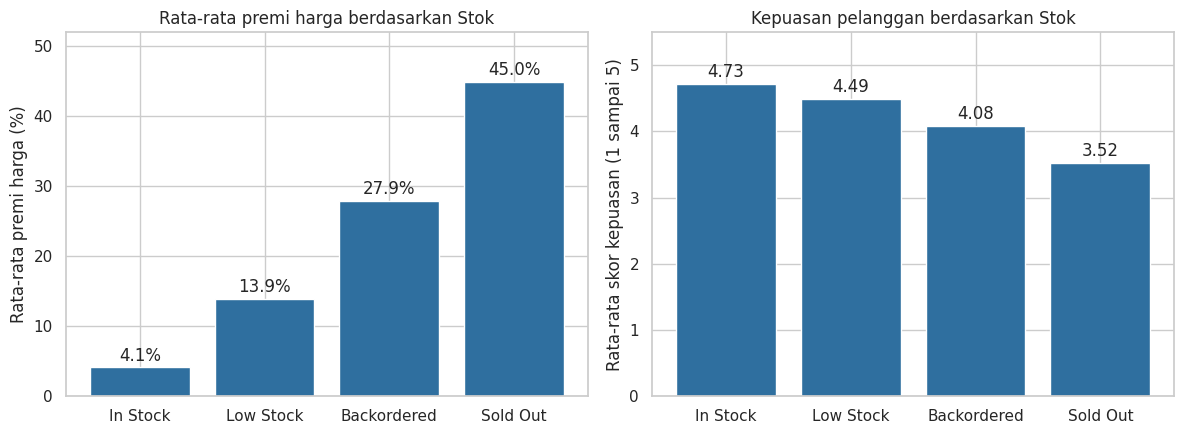

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bar = axes[0].bar(stok.index, stok["price_premium_pct"], color=BIRU)
axes[0].bar_label(bar, fmt="%.1f%%", padding=2)
axes[0].set_title("Rata-rata premi harga berdasarkan Stok")
axes[0].set_ylabel("Rata-rata premi harga (%)")
axes[0].set_ylim(0, 52)

bar = axes[1].bar(stok.index, stok["customer_satisfaction_score"], color=BIRU)
axes[1].bar_label(bar, fmt="%.2f", padding=2)
axes[1].set_title("Kepuasan pelanggan berdasarkan Stok")
axes[1].set_ylabel("Rata-rata skor kepuasan (1 sampai 5)")
axes[1].set_ylim(0, 5.5)

plt.tight_layout()
plt.show()

Pembeli yang mendapat barang berstatus In Stock membayar rata-rata sekitar 4% di atas harga resmi. Untuk status Sold Out angkanya sekitar 45%. Skor kepuasan bergerak ke arah sebaliknya: 4,73 untuk In Stock dan 3,52 untuk Sold Out.

### 3.7 Korelasi antar kolom angka

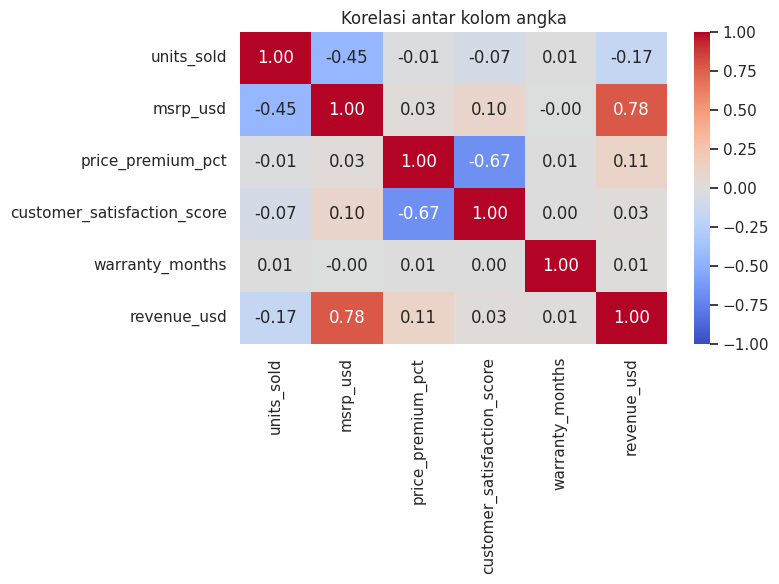

In [21]:
kolom_angka = ["units_sold", "msrp_usd", "price_premium_pct",
               "customer_satisfaction_score", "warranty_months", "revenue_usd"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[kolom_angka].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Korelasi antar kolom angka")
plt.tight_layout()
plt.show()

Ada tiga hubungan yang terlihat jelas:

- `revenue_usd` dan `msrp_usd` berkorelasi kuat (0,78). Masuk akal: GPU yang harganya lebih mahal menghasilkan pendapatan per transaksi yang lebih besar.
- `units_sold` dan `msrp_usd` berkorelasi negatif (-0,45). GPU yang lebih murah terjual dalam jumlah unit lebih banyak per transaksi.
- `price_premium_pct` dan `customer_satisfaction_score` berkorelasi negatif cukup kuat (-0,67). Makin tinggi premi harga, makin rendah kepuasan, dan ini sejalan dengan temuan di status stok.

Kolom lainnya, termasuk `warranty_months`, hampir tidak berhubungan dengan kolom mana pun.

## 4. Kesimpulan

1. GPU data center hanya 15% transaksi tetapi 59% pendapatan. Penyebabnya harga per unit yang jauh lebih tinggi.
2. Model terlaris tergantung ukurannya. B200 terbesar dari sisi pendapatan, RTX 5070 terbesar dari sisi unit.
3. Channel enterprise sangat penting. Cloud Provider dan Direct Enterprise hanya 13% transaksi tetapi sekitar 50% pendapatan. Wilayah tidak banyak mengubah gambaran ini.
4. Pendapatan bulanan naik sampai akhir 2025 lalu mendatar. Juni 2026 lebih rendah, tetapi perlu dicek apakah datanya lengkap.
5. Stok yang menipis berarti harga naik dan kepuasan turun. Sold Out dibeli sekitar 45% di atas MSRP dengan skor kepuasan 3,52, sedangkan In Stock sekitar 4% dengan skor 4,73.

Saran kalau ini data real: laporan penjualan sebaiknya memisahkan GPU konsumen dan data center, karena rata-rata gabungan menutupi perbedaan yang besar. Ketersediaan stok juga perlu dipantau, terutama untuk produk berstatus Sold Out dan Backordered.

## 5. Keterbatasan

- Datanya sintetis. Selain unit per transaksi yang tidak terpengaruh stok, segmen dan channel juga terkunci pada jenis GPU tertentu (misalnya Retail/Etail hanya menjual GPU konsumen). Hasil di sini menggambarkan isi dataset, bukan perilaku pasar di real life.
- Tidak ada data biaya atau margin, jadi saya tidak bisa menjawab model mana yang paling menguntungkan.
- Pendapatan add-on tidak tercatat terpisah, jadi pengaruh add-on tidak bisa diukur.